In [1]:
%env XLA_PYTHON_CLIENT_PREALLOCATE=false
from functools import partial
import numpy as np

import jax
import jax.numpy as jnp

import doe
import doe.secret

import matplotlib.pyplot as plt

env: XLA_PYTHON_CLIENT_PREALLOCATE=false


In [2]:
with open('../config/parameters-123456789.yaml', 'r') as f:
    import yaml
    PARAMETERS = yaml.safe_load(f)

timestamps = jnp.linspace(0, 30, num=9 + 2)[1:-1]
SIGMA_NOISE = 0.025
TEMPERATURE_RANGE = (0.0, 100.0)

E_fixed = 0.5

CONCENTRATIONS = {
    'A': 3.0,
    'B': 3.0,
    'E': 3.0e-3
}

In [3]:
def initial_conditions(conditions):
    solutions = conditions[0]
    temperature = conditions[1]

    A0, B0 = solutions, solutions
    total = A0 + B0 + E_fixed
    A0 = CONCENTRATIONS['A'] * A0 / total
    B0 = CONCENTRATIONS['B'] * B0 / total
    E = CONCENTRATIONS['E'] * E_fixed / total

    return A0, B0, E, temperature

def euler(kinetics):
    @partial(jax.jit, static_argnames=('n', 'horizon'))
    def solve(conditions, n: int=1024, horizon: float=30.0):
        A0, B0, E, temperature = initial_conditions(conditions)
        dt = horizon / n
    
        def euler(state, _):
            A = state
            delta_A = A0 - A
            B = B0 - delta_A
            C, D = delta_A, delta_A
            rate = kinetics(A, B, C, D, E, temperature, PARAMETERS)

            updated = A - dt * rate

            return updated, updated

        _, trajectory = jax.lax.scan(euler, init=A0, xs=None, length=n)
        index = jnp.round(timestamps / dt).astype(int)
        observed = jnp.take_along_axis(trajectory, index, axis=0)

        return observed

    return jax.vmap(solve, in_axes=0, out_axes=0)

In [4]:
target = euler(doe.secret.enzyme.kinetics)
reference = euler(doe.secret.mm.kinetics)

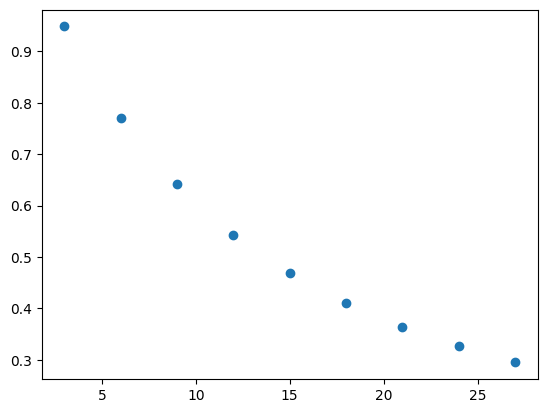

In [5]:
plt.scatter(timestamps, target(jnp.array([[1.0, 20.0]]))[0])

In [6]:
A_grid, temperature_grid = jnp.linspace(0, 1, num=127), jnp.linspace(0, 100, num=129)

grid = jnp.stack(jnp.meshgrid(A_grid, temperature_grid, indexing='ij'), axis=-1)

In [7]:
target_grid = jax.vmap(target, in_axes=0)(grid)
reference_grid = jax.vmap(reference, in_axes=0)(grid)

In [8]:
error = jnp.mean(jnp.abs(target_grid - reference_grid), axis=-1)

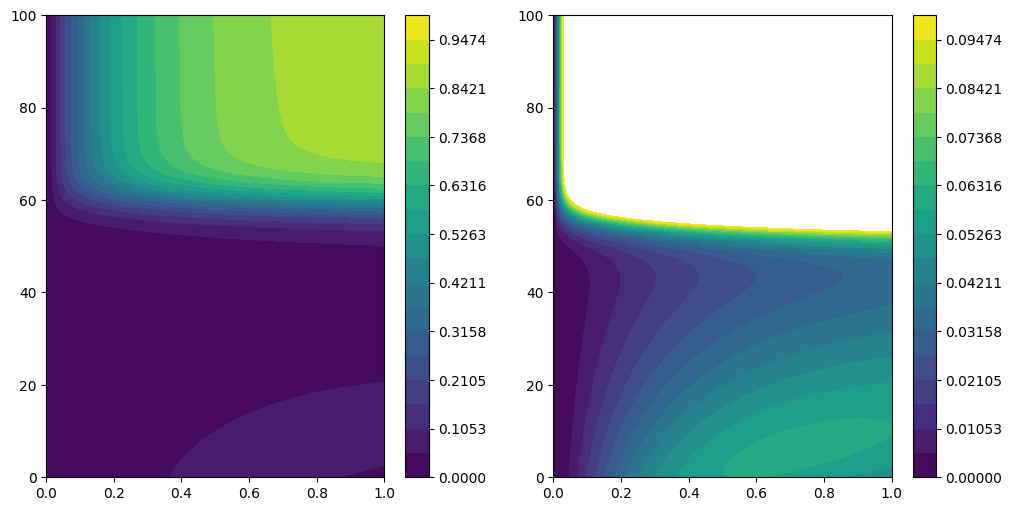

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6))
c = axes[0].contourf(A_grid, temperature_grid, error.T, levels=jnp.linspace(0, 1, num=20))
plt.colorbar(c, ax=axes[0])
c = axes[1].contourf(A_grid, temperature_grid, error.T, levels=jnp.linspace(0, 0.1, num=20))
plt.colorbar(c, ax=axes[1])

In [10]:
SCALE_A = 1.0
SCALE_T = 50
SCALE_t = 5

SCALE = jnp.array([SCALE_A, SCALE_T, SCALE_t])
SIGMA_W = 1.0

def kernel(x1, x2):
    d = (x1 - x2) / SCALE
    return SIGMA_W * jnp.exp(-jnp.sum(jnp.square(d), axis=-1))

gp = doe.gp.GP(kernel=kernel, noise=SIGMA_NOISE)

def combine(conditions, obs=None, ts=None):
    if ts is None:
        ts = timestamps

    n_t, = ts.shape
    n, _ = conditions.shape

    conditions = jnp.broadcast_to(conditions[:, None, :], shape=(n, n_t, 2))
    t = jnp.broadcast_to(ts[None, :, None], shape=(n, n_t, 1))
    
    X = jnp.concatenate([conditions, t], axis=-1)
    X = jnp.reshape(X, shape=(n * n_t, 3))
    if obs is None:
        return X
    else:
        y = jnp.reshape(obs, shape=(n * n_t, ))
        return X, y

In [11]:
c = jnp.array([[1.0, 20.0]])
c_test2 = jnp.array([[1.0, 30.0]])
c_test3 = jnp.array([[0.75, 20.0]])

ts_test = jnp.linspace(0, 30, num=128)

obs = target(c)

X, y = combine(c, obs)
X_test1 = combine(c, ts=ts_test)
X_test2 = combine(c_test2, ts=ts_test)
X_test3 = combine(c_test3, ts=ts_test)

In [12]:
state = gp.fit(X, y)
m1, s1 = gp.predict(state, X_test1)
m2, s2 = gp.predict(state, X_test2)
m3, s3 = gp.predict(state, X_test3)

std1, std2, std3 = jnp.sqrt(s1), jnp.sqrt(s2), jnp.sqrt(s3)

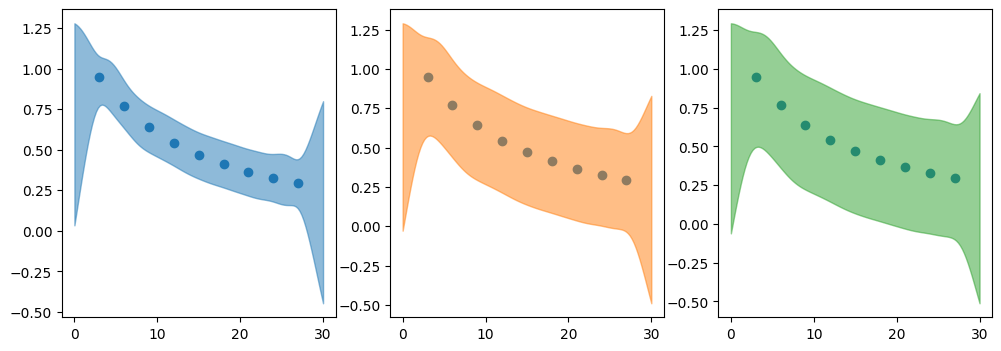

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for i in range(3):
    axes[i].scatter(X[:, 2], y, color=plt.cm.tab10(0))
axes[0].fill_between(ts_test, m1 - std1, m1 + std1, color=plt.cm.tab10(0), alpha=0.5)
axes[1].fill_between(ts_test, m2 - std2, m2 + std2, color=plt.cm.tab10(1), alpha=0.5)
axes[2].fill_between(ts_test, m3 - std3, m3 + std3, color=plt.cm.tab10(2), alpha=0.5)

In [14]:
As, temperatures = jnp.linspace(0, 1, num=31), jnp.linspace(0, 100, num=33)
possible = jnp.stack(jnp.meshgrid(As, temperatures, indexing='ij'), axis=-1)
possible = jnp.reshape(possible, shape=(-1, 2))

In [85]:
MARGIN = SIGMA_NOISE

def acquisition(conditions, state):
    X = combine(conditions)
    mean, var = gp.predict(state, X)

    y_ref = reference(conditions)
    y_ref_ = jnp.reshape(y_ref, shape=(-1, ))

    acq = gp.bald(mean, var, y_ref_, MARGIN)
    acq = jnp.reshape(acq, shape=(-1, timestamps.shape[0]))
    acq = jnp.sum(acq, axis=-1)

    mean = jnp.reshape(mean, shape=(-1, timestamps.shape[0]))

    diff = np.mean(mean - y_ref, axis=-1)

    return diff, acq

In [86]:
rng = jax.random.PRNGKey(123)
rng, key_A, key_T = jax.random.split(rng, num=3)

n_train = 32
c_train = jnp.stack([
    jax.random.uniform(key_A, shape=(n_train, )),
    jax.random.uniform(key_T, minval=0.0, maxval=100.0, shape=(n_train, )),
], axis=-1)
obs_train = target(c_train)

X_train, y_train = combine(c_train, obs_train)
state = gp.fit(X_train, y_train)

In [87]:
diff, acq = acquisition(possible, state)

In [88]:
acq = acq.reshape((As.shape[0], temperatures.shape[0]))
diff = diff.reshape((As.shape[0], temperatures.shape[0]))

In [89]:
error

Array([[0.0000000e+00, 0.0000000e+00, 0.0000000e+00, ..., 0.0000000e+00,
        0.0000000e+00, 0.0000000e+00],
       [1.4473229e-04, 1.4065309e-04, 1.3675148e-04, ..., 1.8239165e-02,
        1.8233478e-02, 1.8227808e-02],
       [7.2474487e-04, 7.0533075e-04, 6.8646175e-04, ..., 4.8041400e-02,
        4.8031379e-02, 4.8021358e-02],
       ...,
       [4.8867557e-02, 5.0287742e-02, 5.1592495e-02, ..., 8.7917721e-01,
        8.7936747e-01, 8.7955117e-01],
       [4.8617382e-02, 5.0046738e-02, 5.1364686e-02, ..., 8.7952805e-01,
        8.7972003e-01, 8.7990528e-01],
       [4.8366282e-02, 4.9806938e-02, 5.1133405e-02, ..., 8.7985939e-01,
        8.8005292e-01, 8.8024002e-01]], dtype=float32)

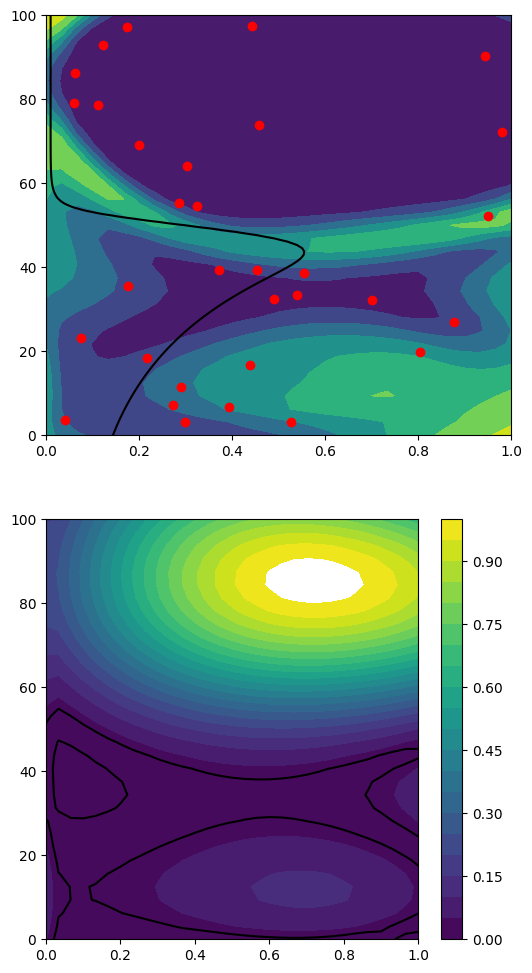

In [92]:
fig, axes = plt.subplots(2, 1, figsize=(6, 12))
axes[0].contourf(As, temperatures, acq.T)
axes[0].contour(A_grid, temperature_grid, (error - MARGIN).T, levels=[0.0], colors='black', zorder=1000)
axes[0].scatter(c_train[:, 0], c_train[:, 1], color='red')

c = axes[1].contourf(As, temperatures, jnp.abs(diff).T, levels=np.linspace(0.0, 1, num=21))
plt.colorbar(c, ax=axes[1])
axes[1].contour(As, temperatures, jnp.abs(diff).T, levels=[MARGIN], colors='black', zorder=1000)